In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    number1: int
    number2: int
    operation: str
    finalNumber: int   

In [3]:
def adder(state: AgentState) -> AgentState:
    """This node adds two numbers."""
    state['finalNumber'] = state['number1'] + state['number2']
    return state

In [4]:
def subtractor(state: AgentState) -> AgentState:
    """This node subtracts two numbers."""
    state['finalNumber'] = state['number1'] - state['number2']
    return state

In [5]:
def decide_next_node(state: AgentState) -> str:
    """Decides the next node based on the operation."""
    if state['operation'] == '+':
        return 'addition_operation'
    elif state['operation'] == '-':
        return 'subtraction_operation'
    else:
        raise ValueError("Unsupported operation")

In [6]:
workflow = StateGraph(AgentState)
workflow.add_node("add_node", adder)
workflow.add_node("subtract_node", subtractor)
workflow.add_node("router_node", lambda state: state)  # Dummy node for routing

# Define the simplest possible path
workflow.add_edge(START, "router_node")
workflow.add_conditional_edges(
    "router_node", 
    decide_next_node, 
    {
      #edge_name: target_node  
    'addition_operation': 'add_node',
    'subtraction_operation': 'subtract_node'
    })

workflow.add_edge("add_node", END)
workflow.add_edge("subtract_node", END)

# Compile the graph into an executable app
app = workflow.compile()


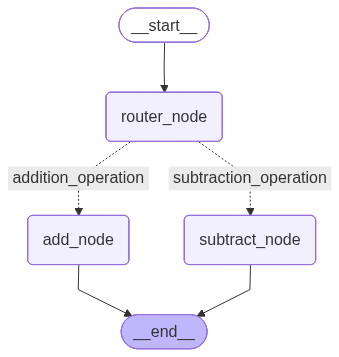

In [7]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [10]:
initial_state1 =AgentState(number1=10, number2=5, operation='+', finalNumber=0)
initial_state2 =AgentState(number1=10, number2=5, operation='-', finalNumber=0)
result = app.invoke(initial_state2)
print(result)
print(result['finalNumber'])

{'number1': 10, 'number2': 5, 'operation': '-', 'finalNumber': 5}
5
